### Programming for Biomedical Informatics
#### Week 3 - Data Integration & Summary Analysis

Using some of the skills we've developed working with eUtils we're now going to take two different lists of genes that use different identifiers convert them to NCBI Gene IDs and then use these to merge the data together. With the final merged data we will do some calculations and plots.

In [1]:
'''In this script we are going to directly query eUtils using the requests library. This is because it allows us to easily specify the parameters and use the history feature of eUtils to make large queries efficiently.
In the code below you should begin to see a pattern for how we approach the mapping process.'''

# Preliminaries
import urllib.request

# we will use this to allow us to search the XML content retutned by the eUtils API
import xml.etree.ElementTree as ET

# load my API key from the file
# load my API key from the file
with open('../../bio_api_keys/ncbi.txt', 'r') as file:
    api_key = file.read().strip()

with open('../../bio_api_keys//ncbi_email.txt', 'r') as file:
    email = file.read().strip()

In [2]:
# Step 1 - Load the two lists that we cannot currenly combine

'''The first file contains a list of gene symbols

e.g.
GeneSymbol
ADAM10
ADAM17
APP
NAE1
APBB1
GAPDH
BACE1

The second file contains a list of RefSeq transcripts (mRNA), and their associated GO terms:

e.g.
RefSeqID        GOTerm  Description
NM_001320570    GO:0003824      catalytic activity
NM_001320570    GO:0016787      hydrolase activity
NM_001320570    GO:0140096      catalytic activity, acting on a protein
NM_001320570    GO:0043226      organelle
NM_001320570    GO:0005634      nucleus
NM_001320570    GO:0005794      Golgi apparatus

We are going to convert Gene Symbols and Refseq IDs to NCBI Gene IDs, and then combine the two lists into a single table.
'''

import pandas as pd

# Load the gene symbols as a pandas dataframe
gene_symbols = pd.read_csv('GeneSymbols.tsv', sep='\t', header=0)

# Load the RefSeq data as a pandas dataframe
transcript_data = pd.read_csv('transcript_functions.tsv', sep='\t', header=0)

In [3]:
# look at the first few rows
gene_symbols.head()

,GeneSymbol
0,ADAM10
1,ADAM17
2,APP
3,NAE1
4,APBB1


In [4]:
# look at the first few rows
transcript_data.head()

,RefSeqID,GOTerm,Description
0,NM_001320570,GO:0003824,catalytic activity
1,NM_001320570,GO:0016787,hydrolase activity
2,NM_001320570,GO:0140096,"catalytic activity, acting on a protein"
3,NM_001320570,GO:0043226,organelle
4,NM_001320570,GO:0005634,nucleus


In [5]:
#Step 2a - Use eSearch to find the internal NCBI ids for the gene symbols
# Here we have a list of gene symbols and we want to convert them into gene ids.
# First we are going to create a query string that we can use to search the gene database in NCBI.
# We will then use the eSearch API to search the gene database and get the gene ids for the gene symbols.

# set the database
db = 'gene'

# convert the gene symbols to a list
gene_symbols_list = gene_symbols['GeneSymbol'].tolist()

# create a string with where gene_symbols have the [Gene] tag attached and are separated by 'OR'
# this is how we can perform long queries using eSearch
gene_symbols_query = ' OR '.join([f'{gene}[Gene]' for gene in gene_symbols_list])

# be sure to restrict our search so that we get exactly what we intend
# add human[Organism] and ( to the start of the string and ) to the end of the string
gene_symbols_query = f'(human[Organism]) AND ({gene_symbols_query})'

# Define the parameters for the eSearch request
# This can be nicely done using a dictionary
# Note we include the history feature of eUtils to allow us to make large queries efficiently
esearch_params = {
    'db': db,
    'term': gene_symbols_query,
    'api_key': api_key,
    'email': email,
    'usehistory': 'y'
}

# encode the parameters so they can be passed to the API
encoded_data = urllib.parse.urlencode(esearch_params).encode('utf-8')

# the base request url for eSearch
url = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"

# make the request
request = urllib.request.Request(url, data=encoded_data)
response = urllib.request.urlopen(request)

# read into an XML object
esaerch_data_XML = ET.fromstring(response.read())

# Extract WebEnv and QueryKey
# Here we use ElementTree to extract the WebEnv and QueryKey from the XML response
# We will use these to fetch the gene ids in the next step using eSummary
webenv = esaerch_data_XML.find('WebEnv').text
query_key = esaerch_data_XML.find('QueryKey').text
count = esaerch_data_XML.find('Count').text

print('webenv:', webenv, 'query_key:', query_key, 'count:', count)

webenv: MCID_68f666cb1d851b19f70d408a query_key: 1 count: 449


In [8]:
# Step 2b - Use eSummary to get the gene ids from the internal NCBI ids
# Define the parameters for the eSummary request
# Note how this is similar to above, but now we don't need to include the search term
esummary_params = {
    'db': 'gene',
    'query_key': query_key,
    'WebEnv': webenv,
    'api_key': api_key,
    'email': email
}

# encode the parameters so they can be passed to the API
encoded_data = urllib.parse.urlencode(esummary_params).encode('utf-8')

# the base request url for eSummary
url = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi"

# make the request
request = urllib.request.Request(url, data=encoded_data)
response = urllib.request.urlopen(request)

#read into an XML object
esummary_data_XML = ET.fromstring(response.read())

# take a look
import xml.dom.minidom

xml_str = ET.tostring(esummary_data_XML, encoding='utf-8')
dom = xml.dom.minidom.parseString(xml_str)
print(dom.toprettyxml())

# Extract the gene ids
# We are now returning an eSummary XML object that contains the gene ids for the gene symbols we searched for.
# Each type of record you return from NCBI can have different XML structure so you often need to print out the XML to see how to extract the information you need.
# The best way to do this is to develop the script for a small number of records and then scale up to the full dataset.
gene_ids = {}
for docsum in esummary_data_XML.findall('DocumentSummarySet/DocumentSummary'):
    gene_symbol = docsum.find('Name').text
    gene_id = docsum.attrib['uid']
    gene_ids[gene_symbol] = gene_id

# convert the gene_ids dictionary to a pandas dataframe
gene_ids_df = pd.DataFrame(gene_ids.items(), columns=['GeneSymbol', 'GeneID'])

# look at the first few rows
gene_ids_df.head()

<?xml version="1.0" ?>
<eSummaryResult>
	

	<DocumentSummarySet status="OK">
		

		<DbBuild>Build250930-2320m.1</DbBuild>
		


		<DocumentSummary uid="348">
			
	
			<Name>APOE</Name>
			
	
			<Description>apolipoprotein E</Description>
			
	
			<Status>0</Status>
			
	
			<CurrentID>0</CurrentID>
			
	
			<Chromosome>19</Chromosome>
			
	
			<GeneticSource>genomic</GeneticSource>
			
	
			<MapLocation>19q13.32</MapLocation>
			
	
			<OtherAliases>AD2, APO-E, ApoE4, LDLCQ5, LPG</OtherAliases>
			
	
			<OtherDesignations>apolipoprotein E|apolipoprotein E3</OtherDesignations>
			
	
			<NomenclatureSymbol>APOE</NomenclatureSymbol>
			
	
			<NomenclatureName>apolipoprotein E</NomenclatureName>
			
	
			<NomenclatureStatus>Official</NomenclatureStatus>
			
	
			<Mim>
				
		
				<int>107741</int>
				
	
			</Mim>
			
	
			<GenomicInfo>
				
		
				<GenomicInfoType>
					
			
					<ChrLoc>19</ChrLoc>
					
			
					<ChrAccVer>NC_000019.10</ChrAccVer>
					
			
					<ChrStart>44905795</ChrSta

,GeneSymbol,GeneID
0,APOE,348
1,TNF,7124
2,IL6,3569
3,APP,351
4,KRAS,3845


In [7]:
gene_ids_df.sort_values(by = 'GeneSymbol')

,GeneSymbol,GeneID
58,ADAM10,102
41,ADAM17,6868
177,ADRM1,11047
19,AGER,177
6,AKT1,207
...,...,...
368,WNT8B,7479
319,WNT9A,7483
312,WNT9B,7484
64,XBP1,7494


In [9]:
gene_ids_df.dropna()

,GeneSymbol,GeneID
0,APOE,348
1,TNF,7124
2,IL6,3569
3,APP,351
4,KRAS,3845
...,...,...
407,COXFA4P1,360165
408,RNU1-93P,106480180
409,RNU6-664P,106479861
410,KNS1,3830


In [10]:
# Step 3a - Use eSearch to find the internal NCBI IDd for the RefSeq transcript accessions

# get all the refseqids into a list
transcript_ids = transcript_data['RefSeqID'].dropna().unique()

# create a string with where refseq_ids have the [ACCN] tag attached and are separated by 'OR'
# note that this time we are using the RefSeq database ids which are nucleotide entries so we need to modify the query
transcript_ids_query = ' OR '.join([f'{transcript_id}[ACCN]' for transcript_id in transcript_ids])

# add human[Organism] and ( to the start of the string and ) to the end of the string
transcript_ids_query = f'(human[Organism]) AND ({transcript_ids_query})'

# Define the parameters for the eSearch request
esearch_params = {
    'db': 'nucleotide',
    'term': transcript_ids_query,
    'api_key': api_key,
    'email': email,
    'usehistory': 'y'
}

# encode the parameters so they can be passed to the API
encoded_data = urllib.parse.urlencode(esearch_params).encode('utf-8')

# the base request url for eSearch
url = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"

# make the request
request = urllib.request.Request(url, data=encoded_data)
response = urllib.request.urlopen(request)

# read into an XML object
esaerch_data_XML = ET.fromstring(response.read())

# Extract WebEnv and QueryKey
webenv = esaerch_data_XML.find('WebEnv').text
query_key = esaerch_data_XML.find('QueryKey').text
count = esaerch_data_XML.find('Count').text

print('webenv:', webenv, 'query_key:', query_key, 'count:', count)

webenv: MCID_68f680aec05e9db7d20a0e3d query_key: 1 count: 1308


In [11]:
# Step 3b - Use eSummary to get the internal NCBI ids themselves

# Define the parameters for the eSummary request
esummary_params = {
    'db': 'nucleotide',
    'query_key': query_key,
    'WebEnv': webenv,
    'api_key': api_key,
    'email': email
}

encoded_data = urllib.parse.urlencode(esummary_params).encode('utf-8')

url = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi"

request = urllib.request.Request(url, data=encoded_data)
response = urllib.request.urlopen(request)

print(response)

# read into an XML object
esummary_data_XML = ET.fromstring(response.read())

# Extract the gene ids
transcript_nucleotide_ids = {}
for docsum in esummary_data_XML.findall('DocSum'):
    gi_id = docsum.find('Id').text
    accession = docsum.find('Item[@Name="Caption"]').text
    transcript_nucleotide_ids[accession] = gi_id

print(transcript_nucleotide_ids)

{'NM_001410889': '2287478764', 'NM_001414249': '2329567344', 'NM_001414250': '2329567342', 'NM_001414255': '2329567276', 'NM_001414252': '2329567268', 'NM_001414245': '2329567254', 'NM_001414248': '2329567240', 'NM_001414244': '2329567156', 'NM_001414254': '2329567149', 'NM_001414247': '2329567141', 'NM_001414253': '2329567122', 'NM_001414251': '2329567113', 'NM_001414246': '2329567107', 'NM_002336': '1519312550', 'NM_002224': '1519241671', 'NM_020142': '2036580767', 'NM_001394960': '2036580660', 'NM_001394961': '2036580338', 'NM_002489': '1519314955', 'NM_001243771': '1890335682', 'NM_001243772': '1890327963', 'NM_001145646': '1890263809', 'NM_016022': '1889738109', 'NM_031301': '1519245325', 'NM_001077628': '1519243771', 'NM_001407446': '2248185749', 'NM_001407453': '2248185745', 'NM_001407449': '2248185735', 'NM_001407469': '2248185728', 'NM_001407467': '2248185722', 'NM_001407456': '2248185718', 'NM_001407452': '2248185716', 'NM_001407457': '2248185714', 'NM_001407458': '2248185701

In [12]:
# Step 3c - Use eLink to link the nucleotide ids to the gene ids

# NB we are taking advantage of NCBIs internal object linking framework (which include LinkOuts to other databases)
# In this case we are wanting to link from the nucleotide database to the gene database

'''We have to be careful how we us eLink for mapping. If we pass a list of Ids in a comma separated list it will do the mapping in bulk
this means that we will recover all the mappings but just as a list of geneids; we wont know which nucleotide id they are associated with.
If we want this 1:1 mapping we have to pass the list of nucleotide ids in the format &id=gi_id1&id=gi_id2&id=gi_id3 rather than &id=gi_id1,gi_id2,gi_id3
This way we will get a link explictly for each nucleotide id.
'''
# create a string where each gi id is preceded by '&id=' and separated by commas
elink_search = [f'&id={value}' for key, value in transcript_nucleotide_ids.items()]
elink_search = ''.join(elink_search)

#use eLink to link the gi ids to the gene ids
# Define the parameters for the eLink request
# We don't need to use the history feature here as we are only linking a small number of ids
elink_params = {
    'dbfrom': 'nucleotide',
    'db': 'gene',
    'api_key': api_key,
    'email': email
}

encoded_data = urllib.parse.urlencode(elink_params).encode('utf-8')

#add the elink_search to the end of the encoded_data
encoded_data = encoded_data + elink_search.encode('utf-8')

# the base request url for eLink
url = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/elink.fcgi"

# make the request
request = urllib.request.Request(url, data=encoded_data)
response = urllib.request.urlopen(request)

# read into an XML object
try:
    elink_data_XML = ET.fromstring(response.read())
except http.client.IncompleteRead as e:
    elink_data_XML = ET.fromstring(e.partial)

# Extract the DbFrom Id element and the DbTo Id element
nucleotide2gene_ids = {}

# we are going to loop through each LinkSet and extract the nucleotide id and the gene id
for linkset in elink_data_XML.findall('LinkSet'):
    try:
        gi_id = linkset.find('IdList/Id').text
        gene_id = linkset.find('LinkSetDb/Link/Id').text
        nucleotide2gene_ids[gi_id] = gene_id
    except:
        pass
print(nucleotide2gene_ids)

{'2287478764': '4720', '2329567344': '4040', '2329567342': '4040', '2329567276': '4040', '2329567268': '4040', '2329567254': '4040', '2329567240': '4040', '2329567156': '4040', '2329567149': '4040', '2329567141': '4040', '2329567122': '4040', '2329567113': '4040', '2329567107': '4040', '1519312550': '4040', '1519241671': '3710', '2036580767': '56901', '2036580660': '56901', '2036580338': '56901', '1519314955': '4697', '1890335682': '51107', '1890327963': '51107', '1890263809': '83464', '1889738109': '51107', '1519245325': '83464', '1519243771': '51107', '2248185749': '324', '2248185745': '324', '2248185735': '324', '2248185728': '324', '2248185722': '324', '2248185718': '324', '2248185716': '324', '2248185714': '324', '2248185701': '324', '2248185691': '324', '2248185641': '324', '2248185631': '324', '2248185577': '324', '2248185573': '324', '2248185565': '324', '2248185557': '324', '2248185539': '324', '2248185529': '324', '2248185527': '324', '2248185515': '324', '1890273911': '57142

In [13]:
# Step 4 - Now all the hard work mapping has been done we can begin to combine the data

# convert the refseq2nucleotide_ids and transcript2gene_ids to pandas dataframes
refseq2nucleotide_ids_df = pd.DataFrame(transcript_nucleotide_ids.items(), columns=['RefSeqID', 'nucleotideID'])
transcript2gene_ids_df = pd.DataFrame(nucleotide2gene_ids.items(), columns=['nucleotideID', 'GeneID'])

# merge the refseq2nucleotide_ids_df and transcript2gene_ids_df on the nucleotideID column
refseq2gene_ids_df = pd.merge(refseq2nucleotide_ids_df, transcript2gene_ids_df, on='nucleotideID')

# we now have a table that maps RefSeqIDs to GeneIDs
refseq2gene_ids_df.head()

,RefSeqID,nucleotideID,GeneID
0,NM_001410889,2287478764,4720
1,NM_001414249,2329567344,4040
2,NM_001414250,2329567342,4040
3,NM_001414255,2329567276,4040
4,NM_001414252,2329567268,4040


In [14]:
# Step 5 - Now we can merge the RefSeq meta-data from the very start of the notebook to the gene ids

# merge the refseq dataframe with the refseq2gene_ids_df dataframe on the RefSeqID column
refseq_gene_ids = pd.merge(transcript_data, refseq2gene_ids_df, on='RefSeqID')

#drop the nucleotideID column
refseq_gene_ids = refseq_gene_ids.drop(columns=['nucleotideID'])

# we now have a table that maps RefSeqIDs to GeneIDs and contains the meta-data
refseq_gene_ids.head()

,RefSeqID,GOTerm,Description,GeneID
0,NM_001320570,GO:0003824,catalytic activity,102
1,NM_001320570,GO:0016787,hydrolase activity,102
2,NM_001320570,GO:0140096,"catalytic activity, acting on a protein",102
3,NM_001320570,GO:0043226,organelle,102
4,NM_001320570,GO:0005634,nucleus,102


In [15]:
# Step 6 - Finally we can merge the RefSeq data and the gene symbols data to get our finished table

# merge the gene_ids_df with the refseq_gene_ids dataframe on the GeneID column
combined_df = pd.merge(gene_ids_df, refseq_gene_ids, on='GeneID')

# we now have a table that maps GeneSymbols to RefSeqIDs and contains the meta-data
combined_df.head()

,GeneSymbol,GeneID,RefSeqID,GOTerm,Description
0,APOE,348,NM_001302691,GO:0005576,extracellular region
1,APOE,348,NM_001302691,GO:0008289,lipid binding
2,APOE,348,NM_001302691,GO:0005615,extracellular space
3,APOE,348,NM_001302691,GO:0043226,organelle
4,APOE,348,NM_001302691,GO:0005634,nucleus


In [16]:
#Step 8 - Summary Analysis

# We can do lots of different types of analysis on this data, but here's a few simple examples

# use the pivot function in pandas to summarise the number of unique GO terms for each gene symbol sorted by the number of unique GO terms descending
gene_summary = combined_df.pivot_table(index='GeneSymbol', values='GOTerm', aggfunc='nunique').sort_values(by='GOTerm', ascending=False)

# look at the first few rows
gene_summary.head()


,GOTerm
GeneSymbol,
PSEN1,46
SNCA,45
AKT1,44
MTOR,42
APP,42


In [17]:
# count the number of entries for each class of Description entry
description_summary = combined_df['Description'].value_counts()

#print the top 10 using PrettyTable
from prettytable import PrettyTable

description_summary_table = PrettyTable()
description_summary_table.field_names = ['Description', 'Count']

for key, value in description_summary[:10].items():
    description_summary_table.add_row([key, value])

print(description_summary_table)

+----------------------------------+-------+
|           Description            | Count |
+----------------------------------+-------+
|            organelle             |  1151 |
|            signaling             |  707  |
|             nucleus              |  601  |
|        catalytic activity        |  588  |
|             cytosol              |  558  |
|         plasma membrane          |  541  |
| anatomical structure development |  538  |
|          mitochondrion           |  474  |
|       cell differentiation       |  437  |
|      programmed cell death       |  424  |
+----------------------------------+-------+


In [18]:
# use numpy to combine the counts for all but the 10 largest classes into a single class called 'Other' for the description_summary dataframe
import numpy as np

description_summary['Other'] = np.sum(description_summary[10:])

# resort the dataframe
description_summary = description_summary.sort_values(ascending=False)

# drop all but the 11 largest classes
description_summary = description_summary[:10]

# use PrettyTable to print the top 10 classes
description_summary_table = PrettyTable()

description_summary_table.field_names = ['Description', 'Count']

for key, value in description_summary.items():
    description_summary_table.add_row([key, value])

print(description_summary_table)

+----------------------------------+-------+
|           Description            | Count |
+----------------------------------+-------+
|              Other               | 10372 |
|            organelle             |  1151 |
|            signaling             |  707  |
|             nucleus              |  601  |
|        catalytic activity        |  588  |
|             cytosol              |  558  |
|         plasma membrane          |  541  |
| anatomical structure development |  538  |
|          mitochondrion           |  474  |
|       cell differentiation       |  437  |
+----------------------------------+-------+


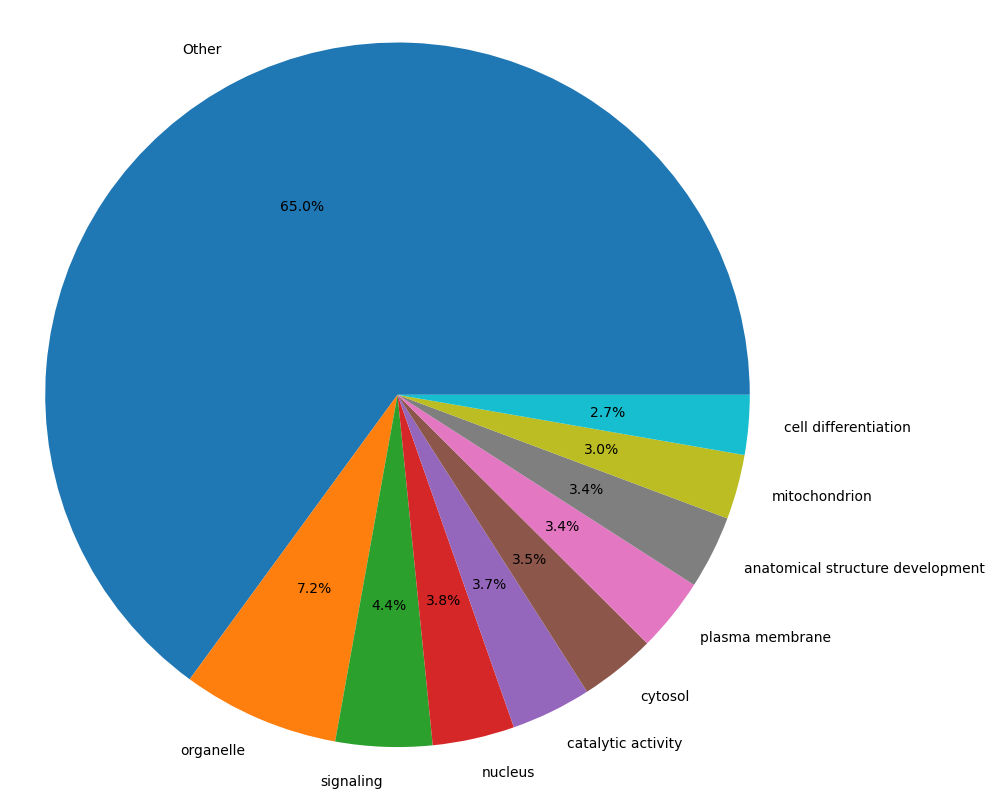

In [19]:
# plot the description_summary dataframe as a pie chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.pie(description_summary, labels=description_summary.index, autopct='%1.1f%%')
plt.axis('equal')
plt.show()